In [ ]:
from pathlib import Path

import pandas as pd

try:
    from sklearn.preprocessing import LabelEncoder
except ImportError:
    LabelEncoder = None

csv_path = Path("sample_data.csv")
if not csv_path.exists():
     raise FileNotFoundError(f"{csv_path} was not found. Add sample_data.csv to {Path.cwd()}.")

df = pd.read_csv(csv_path)
df_label = df.copy()

def encode_column(series):
    if LabelEncoder is not None:
        encoder = LabelEncoder()
        return encoder.fit_transform(series)
    return pd.factorize(series)[0]

df_label["Gender_Encoded"] = encode_column(df_label["Gender"])
df_label["Passed_Encoded"] = encode_column(df_label["passed"])

print("\nLabel encoded data")
print(df_label[["name", "Gender", "Gender_Encoded", "passed", "Passed_Encoded"]])



Label encoded data
     name  Gender  Gender_Encoded passed  Passed_Encoded
0  piyush  Female               0    Yes               1
1   priya    Male               1     No               0
2    brod  Female               0    Yes               1
3   David    Male               1     No               0


In [ ]:
from sklearn.metrics import confusion_matrix

y_true = [1, 0 , 1, 1, 0 ,1 , 0 , 0 , 1, 0 ]
y_pred = [1, 0 , 1, 0 , 1, 1 ,0 ,1,0 , 0]

cm = confusion_matrix(y_true, y_pred)
print("confusion matrix")
print(cm)



confusion matrix
[[3 2]
 [2 3]]


In [ ]:
# mse mean squared error

# 1) take the mistake differnce
# 2) remove the minus sign 
# 3) add
# 4) divide
# 7.5 mean actucally value 

# mse = 62.5


#rmse
# root mean squared error


import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

data = pd.read_csv("student_scores.csv")

x = data[['hours']]
y = data['score']

model = LinearRegression()
model.fit(x, y)
real_scores = y
predicted_scores = [85, 70, 70, 95]

mae = mean_absolute_error(real_scores, predicted_scores)
mse = mean_squared_error(real_scores, predicted_scores)
rmse = np.sqrt(mse)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)

new_hour = float(input('Enter hours = '))
new_pred = model.predict(pd.DataFrame({'hours': [new_hour]}))[0]

print(f'Predicted score for {new_hour} hours = {new_pred:.2f}')

# true , pred  --> divison 



MAE: 7.5
MSE: 62.5
RMSE: 7.905694150420948


MAE: 12.5
MSE: 187.5
RMSE: 13.69
R2: 0.1429


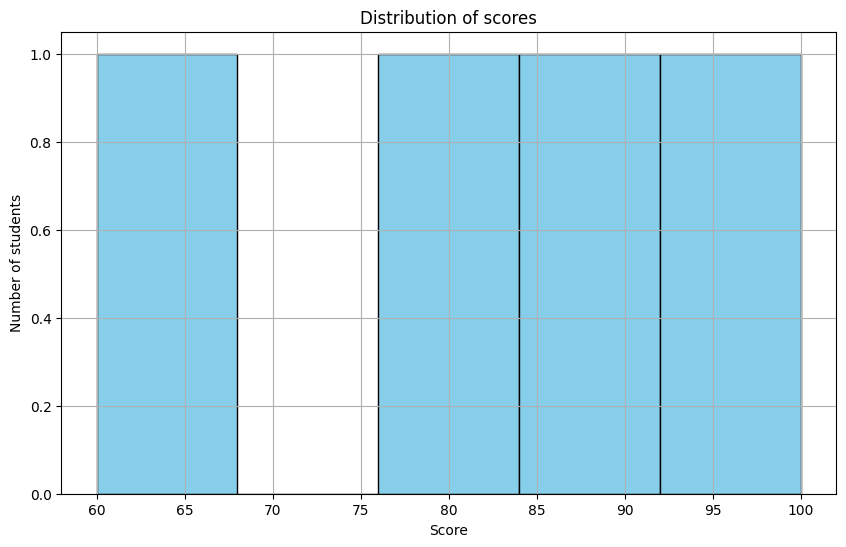

In [2]:
# mat

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

data = pd.read_csv("student_scores.csv")

x = data[['hours']]
y = data['score']

model = LinearRegression()
model.fit(x, y)
predicted_scores = model.predict(x)

# Validate regression
mae = mean_absolute_error(y, predicted_scores)
mse = mean_squared_error(y, predicted_scores)
rmse = np.sqrt(mse)
r2 = r2_score(y, predicted_scores)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

# Histogram
if plt is not None:
    plt.figure(figsize=(10, 6))
    plt.hist(data["score"], bins=5, color="skyblue", edgecolor="black")
    plt.title("Distribution of scores")
    plt.xlabel("Score")
    plt.ylabel("Number of students")
    plt.grid(True)
    plt.show()
else:
    print("matplotlib is not installed, so the histogram was skipped.")





In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = {
    "StudyHours": [1, 2, 3, 4, 5, 6],
    "TestScore": [40, 40, 50, 60, 70, 100],
}

df = pd.DataFrame(data)
X_train, X_test = train_test_split(df, test_size=0.33, random_state=42)

standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df)

minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df)

print("StandardScaler output:")
print(pd.DataFrame(standard_scaled, columns=["StudyHours", "TestScore"]))

print("\nMinMaxScaler output:")
print(pd.DataFrame(minmax_scaled, columns=["StudyHours", "TestScore"]))

print("\nTrain data:")
print(X_train)

print("\nTest data:")
print(X_test)

print("\n MinMax Scaled Output ")
print(pd.DataFrame(minmax_scaled , columns = ["StudyHours" , "TestScore" ]))


x = df[["StudyHours"]]
y = df[["TestScore"]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("\nTraining data")
print(x_train)

print("\nTesting data")
print(x_test)




StandardScaler output:
   StudyHours  TestScore
0    -1.46385  -0.960769
1    -0.87831  -0.960769
2    -0.29277  -0.480384
3     0.29277   0.000000
4     0.87831   0.480384
5     1.46385   1.921538

MinMaxScaler output:
   StudyHours  TestScore
0         0.0   0.000000
1         0.2   0.000000
2         0.4   0.166667
3         0.6   0.333333
4         0.8   0.500000
5         1.0   1.000000

Train data:
   StudyHours  TestScore
5           6        100
2           3         50
4           5         70
3           4         60

Test data:
   StudyHours  TestScore
0           1         40
1           2         40

 MinMax Scaled Output 
   StudyHours  TestScore
0         0.0   0.000000
1         0.2   0.000000
2         0.4   0.166667
3         0.6   0.333333
4         0.8   0.500000
5         1.0   1.000000

Training data
   StudyHours
1           2
3           4
0           1
4           5

Testing data
   StudyHours
5           6
2           3


In [1]:
import pandas as pd

data = {
    "name": ["piyush", "priya", "neha", "riya", "rahul"],

    "phone": ["90930909", "9289186945", "9599508511", "92891933020", "909099099"],
}

df = pd.DataFrame(data)

print("number" , df)



number      name        phone
0  piyush     90930909
1   priya   9289186945
2    neha   9599508511
3    riya  92891933020
4   rahul    909099099


In [7]:
from pathlib import Path
import pandas as pd

try:
    from sklearn.preprocessing import LabelEncoder
except ImportError:
    LabelEncoder = None

# CSV file path
csv_path = Path("sample_data.csv")

# Check if file exists
if not csv_path.exists():
    raise FileNotFoundError(f"{csv_path} not found in {Path.cwd()}")

# Read CSV
df = pd.read_csv(csv_path)

# Copy dataset
df_label = df.copy()

# Encoding function
def encode_columns(series):
    if LabelEncoder is not None:
        encoder = LabelEncoder()
        return encoder.fit_transform(series)
    return pd.factorize(series)[0]

# Encode categorical columns
df_label["Gender_Encoded"] = encode_columns(df_label["Gender"])
df_label["Passed_Encoded"] = encode_columns(df_label["passed"])

# Print result
print("\nLabel encoded data")
print(df_label[["name", "Gender", "Gender_Encoded", "passed", "Passed_Encoded"]])






Label encoded data
     name  Gender  Gender_Encoded passed  Passed_Encoded
0  piyush  Female               0    Yes               1
1   priya    Male               1     No               0
2    brod  Female               0    Yes               1
3   David    Male               1     No               0


In [8]:
from pathlib import Path
import pandas as pd

try:
    from sklearn.preprocessing import LabelEncoder
except ImportError:
    LabelEncoder = None

csv_path = Path("main.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"{csv_path} not found in {Path.cwd()}")

df = pd.read_csv(csv_path)
df_label = df.copy()

def encode_columns(series):
    if LabelEncoder is not None:
        encoder = LabelEncoder()
        return encoder.fit_transform(series)
    return pd.factorize(series)[0]

# Encode categorical columns
df_label["Gender_Encoded"] = encode_columns(df_label["Gender"])
df_label["Passed_Encoded"] = encode_columns(df_label["passed"])

# Print result
print("\nLabel encoded data")
print(df_label[["name", "Gender", "Gender_Encoded", "passed", "Passed_Encoded"]])





Label encoded data
    name  Gender  Gender_Encoded passed  Passed_Encoded
0  piush  Female               0    Yes               1
1    Bob    Male               1     No               0
2   Cara  Female               0    Yes               1
3  David    Male               1     No               0


In [ ]:
#logistic regreesion ---> yes and no
# knn --> sab komain pado raha to hai
# decision tree class --> 
# linear  eqN --> linear regresion
# classififcatation --> catagiers prediction -->  yes and no  
# regression --> prediction --> yes and no 
# decision --> flow chat in only work  used prediction 
# fit()  --> fit kithbham ki exam gaya to likh yad fit()
# regresion --> linean regression prodicting mnumber 


# 5 rows use start
# accuracy is not always the goal

#
# linear regression
#  1-  finds a pattern in old data
# 2 - straight line
#  3- line 
# y = mx + c 
from sklearn.linear_model import LinearRegression

X = [[1], [2], [3], [4], [5]]
y = [10, 30, 50, 70, 90]
model = LinearRegression()
model.fit(X, y)

hours = 6.0
predicted_marks = model.predict([[hours]])[0]
print(f"Based on your hours {hours}, you may score around {predicted_marks:.2f}")

# logic reg only used math ka formula symbolic
# 0  --> no , 1 --> yes



# model --> object
# [[value]]  --> 2d list  --> [6]
# model x = [ [1] , [2] , [3], [4]  , [5]]







In [ ]:
from sklearn.neighbors import KNeighborsClassifier

x = [
    [180, 7],
    [200, 7.5],
    [300, 8],
    [330, 9],
    [360, 9.5]
]

y = [0, 1, 1, 1, 0]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x, y)

weight = 220.0
size = 7.4
prediction = model.predict([[weight, size]])[0]

if prediction == 0:
    print("This is likely an apple.")
else:
    print("This is likely an orange.")


In [ ]:
""" 
is fever > 100 
            yes > fit
            no >maybe
"""

from sklearn.tree import DecisionTreeClassifier

x = [
    [7,3],
    [8,9],[10 ,9],
    [9,3]
]
y = [ 0 , 1 , 1, 0]

model = DecisionTreeClassifier()
model.fit(x, y)
size = 8.0
shade = 8.0

result = model.predict([[size, shade]])[0]

if result == 0:
    print("this is apple")
else: 
    print("this is orange")



